## CN-aware RNA-seq simulation framework


In [87]:
from __future__ import annotations
import numpy as np
import pandas as pd
from scipy.stats import nbinom, norm

from deconveil.utils_fit import *
from deconveil.utils_processing import *

import rpy2.robjects as ro
from rpy2.robjects import pandas2ri, conversion, Formula
import rpy2.robjects.packages as rpackages
from rpy2.robjects.packages import importr

import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from scipy.stats import pearsonr

In [89]:
import pydeseq2
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

from deconveil.dds import deconveil_fit
from deconveil.inference import Inference
from deconveil.default_inference import DefInference
from deconveil.utils_fit import *
from deconveil.utils_processing import *
from deconveil.utils_plot import *
from deconveil import deconveil_fit
from deconveil.ds import deconveil_stats

#### Load TCGA data

In [91]:
rna_counts = load_test_data(
    modality="rna",
    dataset="tcga_brca",
    debug=False,
)
rna_counts = rna_counts.T

metadata = load_test_data(
    modality="metadata",
    dataset="tcga_brca",
    debug=False,
)

cnv = load_test_data(
    modality="cnv",
    dataset="tcga_brca",
    debug=False,
)
cnv = cnv.T

In [93]:
rna_counts.head()

,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2MP1,A3GALT2,A4GALT,A4GNT,AACS,AACSP1,...,ZSWIM6,ZSWIM9,ZW10,ZWILCH,ZWINT,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1
GTEX-13PVQ-1026-SM-5KM3M.1,3502210.0,83739.0,1592.0,17369.0,9842.0,4961.0,377148.0,657.0,156623.0,151.0,...,231243.0,11494.0,41101.0,23345.0,4853.0,93143.0,679.0,97130.0,1819661.0,394464.0
GTEX-18QFQ-0826-SM-718AX.1,5394960.0,155914.0,14511.0,10089.0,11023.0,303.0,278056.0,357.0,385961.0,149.0,...,184259.0,83650.0,123117.0,74837.0,25442.0,320704.0,8603.0,300670.0,1580226.0,918922.0
GTEX-1JN6P-2426-SM-ARL99.1,7136304.0,219925.0,2254.0,12267.0,5955.0,769.0,229205.0,0.0,40360.0,0.0,...,114710.0,22251.0,37669.0,17233.0,4141.0,82340.0,372.0,89483.0,982597.0,339959.0
GTEX-13S86-1226-SM-5S2OA.1,5710693.0,236061.0,932.0,4446.0,12644.0,986.0,468005.0,76.0,177527.0,0.0,...,62143.0,22458.0,73701.0,20962.0,8415.0,111953.0,126.0,94875.0,1060350.0,233669.0
GTEX-132NY-0826-SM-5K7Y7.1,4020951.0,155161.0,6312.0,5744.0,5015.0,76.0,480082.0,1286.0,277306.0,152.0,...,106252.0,28196.0,49946.0,35748.0,6204.0,134309.0,505.0,133562.0,1136263.0,392324.0


In [95]:
metadata.head()

,condition
GTEX-13PVQ-1026-SM-5KM3M.1,A
GTEX-18QFQ-0826-SM-718AX.1,A
GTEX-1JN6P-2426-SM-ARL99.1,A
GTEX-13S86-1226-SM-5S2OA.1,A
GTEX-132NY-0826-SM-5K7Y7.1,A


In [97]:
cnv.head()

,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2MP1,A3GALT2,A4GALT,A4GNT,AACS,AACSP1,...,ZSWIM6,ZSWIM9,ZW10,ZWILCH,ZWINT,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1
GTEX-13PVQ-1026-SM-5KM3M.1,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
GTEX-18QFQ-0826-SM-718AX.1,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
GTEX-1JN6P-2426-SM-ARL99.1,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
GTEX-13S86-1226-SM-5S2OA.1,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
GTEX-132NY-0826-SM-5K7Y7.1,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2


#### QC & filtering

In [99]:
print("Before filtering:", rna_counts.shape, cnv.shape, metadata.shape)
# Reorder cnv to match rna_counts
cnv = cnv.loc[rna_counts.index]
assert (rna_counts.index == metadata.index).all(), "Sample order mismatch between rna_counts and metadata"
assert (cnv.index == rna_counts.index).all(), "Sample order mismatch between cnv and rna_counts"

Before filtering: (400, 17387) (400, 17387) (400, 1)


In [101]:
all_zero_mask = (rna_counts.sum(axis=0) == 0)
print("All-zero genes:", all_zero_mask.sum())
rna_counts = rna_counts.loc[:, ~all_zero_mask]
cnv = cnv.loc[:, ~all_zero_mask]  

All-zero genes: 0


In [103]:
res = filter_low_count_genes(rna_counts, other_dfs=[cnv], min_count=300, min_samples=50)
rna_counts = res["filtered_df"]
cnv = res["other_filtered"][0]
print("After low-count filtering:", rna_counts.shape, cnv.shape)

After low-count filtering: (400, 16252) (400, 16252)


#### Run simulation

In [111]:
cnv = cnv.T
cn_tumor = cnv.iloc[:, 200:400]
cn_tumor = cn_tumor.clip(lower=0, upper=6)
cn_tumor.head()

,TCGA-D8-A1Y1-01A,TCGA-AO-A124-01A,TCGA-AO-A1KS-01A,TCGA-EW-A6SB-01A,TCGA-A8-A08J-01A,TCGA-BH-A0GY-01A,TCGA-AC-A2QJ-01A,TCGA-B6-A401-01A,TCGA-Z7-A8R5-01A,TCGA-A8-A093-01A,...,TCGA-BH-A208-01A,TCGA-A2-A0CL-01A,TCGA-LL-A6FR-01A,TCGA-E9-A1N6-01A,TCGA-AR-A251-01A,TCGA-A2-A4S1-01A,TCGA-E2-A2P5-01A,TCGA-A2-A0EV-01A,TCGA-LL-A6FQ-01A,TCGA-A2-A04T-01A
A2M,3,5,4,6,4,4,2,3,3,3,...,3,4,2,3,2,2,4,2,4,6
A2M-AS1,3,5,4,6,4,4,2,3,3,3,...,3,4,2,3,2,2,4,2,4,6
A2ML1,3,4,4,6,4,4,2,3,3,3,...,3,4,2,5,2,2,4,2,4,6
A2ML1-AS1,3,4,4,6,4,4,2,3,3,3,...,3,4,2,5,2,2,4,2,4,6
A2MP1,3,5,4,6,4,4,2,3,3,3,...,3,4,2,3,2,2,4,2,4,6


In [113]:
cn_normal = cnv.iloc[:, 0:200]
cn_normal = cn_normal.clip(lower=2, upper=2)
cn_normal.head()

,GTEX-13PVQ-1026-SM-5KM3M.1,GTEX-18QFQ-0826-SM-718AX.1,GTEX-1JN6P-2426-SM-ARL99.1,GTEX-13S86-1226-SM-5S2OA.1,GTEX-132NY-0826-SM-5K7Y7.1,GTEX-ZTX8-1226-SM-4YCE9.1,GTEX-UJHI-1426-SM-3DB9C.1,GTEX-15RJE-2626-SM-7KFT1.1,GTEX-ZEX8-2226-SM-57WC6.1,GTEX-1KANA-2026-SM-DIPFB.1,...,GTEX-17F96-2426-SM-7IGLN.1,GTEX-S7SE-0826-SM-4AT4D.1,GTEX-1IDJF-2326-SM-ARL86.1,GTEX-ZF3C-2326-SM-5S2MZ.1,GTEX-1J8EW-2626-SM-CL53E.1,GTEX-R3RS-0626-SM-48FE1.1,GTEX-13O61-1826-SM-5KM4I.1,GTEX-1J8QM-2026-SM-ARZMW.1,GTEX-183FY-1126-SM-7DHLJ.1,GTEX-1B98T-0726-SM-7939J.1
A2M,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
A2M-AS1,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
A2ML1,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
A2ML1-AS1,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
A2MP1,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2


In [117]:
rna_counts.head()

,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2MP1,A3GALT2,A4GALT,A4GNT,AACS,AACSP1,...,ZSWIM6,ZSWIM9,ZW10,ZWILCH,ZWINT,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1
GTEX-13PVQ-1026-SM-5KM3M.1,3502210.0,83739.0,1592.0,17369.0,9842.0,4961.0,377148.0,657.0,156623.0,151.0,...,231243.0,11494.0,41101.0,23345.0,4853.0,93143.0,679.0,97130.0,1819661.0,394464.0
GTEX-18QFQ-0826-SM-718AX.1,5394960.0,155914.0,14511.0,10089.0,11023.0,303.0,278056.0,357.0,385961.0,149.0,...,184259.0,83650.0,123117.0,74837.0,25442.0,320704.0,8603.0,300670.0,1580226.0,918922.0
GTEX-1JN6P-2426-SM-ARL99.1,7136304.0,219925.0,2254.0,12267.0,5955.0,769.0,229205.0,0.0,40360.0,0.0,...,114710.0,22251.0,37669.0,17233.0,4141.0,82340.0,372.0,89483.0,982597.0,339959.0
GTEX-13S86-1226-SM-5S2OA.1,5710693.0,236061.0,932.0,4446.0,12644.0,986.0,468005.0,76.0,177527.0,0.0,...,62143.0,22458.0,73701.0,20962.0,8415.0,111953.0,126.0,94875.0,1060350.0,233669.0
GTEX-132NY-0826-SM-5K7Y7.1,4020951.0,155161.0,6312.0,5744.0,5015.0,76.0,480082.0,1286.0,277306.0,152.0,...,106252.0,28196.0,49946.0,35748.0,6204.0,134309.0,505.0,133562.0,1136263.0,392324.0


In [231]:
rna_counts = rna_counts.T

sim = cn_aware_rna_simulator(
    counts=rna_counts,
    metadata=metadata,
    cn_tumor=cn_tumor,
    cn_normal=cn_normal,      # or None
    n_genes=5000,
    design="~ 1",
    seed=4444,
    inject_del=True,
    #del_frac=0.1,
    del_frac_dcg=0.15,
    del_frac_dsg=0.2,
    frac_cn0=0.0,
    max_log2fc=3.0,
    n_normal_sim=60,          # desired cohort size
    n_tumor_sim=60,   
    bootstrap_cn=True,
    cn_heterogeneity_sd=0.4,
    dsg_strength=(0.8, 1.6), # (1.6, 2.8), (0.8, 1.6)
    dcg_strength=(0.8, 1.6), # (1.4, 2.4), (0.8, 1.6)
)

R callback write-console: estimating size factors
  
R callback write-console: estimating dispersions
  
R callback write-console: gene-wise dispersion estimates
  
R callback write-console: mean-dispersion relationship
  
R callback write-console: final dispersion estimates
  
R callback write-console: fitting model and testing
  
R callback write-console: -- replacing outliers and refitting for 591 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)
  
R callback write-console: estimating dispersions
  
R callback write-console: fitting model and testing
  
R callback write-console: In aggiunta:   
R callback write-console: Messaggio di avvertimento:
  
R callback write-console: In (function (object, test = c("Wald", "LRT"), fitType = c("parametric",  :  
R callback write-console: 
   
R callback write-console:  the design is ~ 1 (just an intercept). is this intended?
  


[Simulator] Using 4988 genes.


#### Explore simulator results

In [233]:
counts_sim  = sim["counts"]
counts_sim = counts_sim.T
counts_sim.head()

,NPFF,MTX2,VGLL4,ZNF451,RPS3A,PCSK7,APOA1,TRAF5,RNU6-817P,ZNF664,...,PPIA,VN2R19P,RPS19,TAT,TTC13,ANKRD46,RPL34P18,NACA,SSX2IP,POU2F2
GTEX-13O61-1826-SM-5KM4I.1,43156,229129,1093735,528958,1800953,736320,16707,146089,504,1137727,...,2335454,8025,746318,302460,265531,256642,78756,2693069,982139,44909
GTEX-15FZZ-0726-SM-7KUFZ.1,3118,118374,497935,144117,1747534,3838498,651,110541,41,1160086,...,257335,11,222213,131944,35813,619,1348472,2596289,71493,11326
GTEX-1HCU8-0126-SM-ADEHH.1,30578,147890,457938,248221,770698,521249,5980,199566,97,1543359,...,306615,463,3268,713849,222081,446089,51945,4284486,342283,35804
GTEX-1F5PL-1026-SM-7RHI1.1,6889,166301,915346,272391,2339657,380322,1,207340,94,346173,...,555,2154,240125,106834,45062,270177,549644,3914219,81805,49069
GTEX-RUSQ-2026-SM-4GIAK.1,723,108094,354197,107820,1922048,1509958,127,166567,18,928850,...,3154804,47,946811,1227828,91791,37272,16725,1334280,73033,19753


In [235]:
cn_df  = sim["CN"]
cn_df = cn_df.T
cn_df.head()

,NPFF,MTX2,VGLL4,ZNF451,RPS3A,PCSK7,APOA1,TRAF5,RNU6-817P,ZNF664,...,PPIA,VN2R19P,RPS19,TAT,TTC13,ANKRD46,RPL34P18,NACA,SSX2IP,POU2F2
GTEX-13O61-1826-SM-5KM4I.1,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
GTEX-15FZZ-0726-SM-7KUFZ.1,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
GTEX-1HCU8-0126-SM-ADEHH.1,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
GTEX-1F5PL-1026-SM-7RHI1.1,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
GTEX-RUSQ-2026-SM-4GIAK.1,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2


In [237]:
truth_df = sim["truth"]
truth_df

,class,beta1,cn_ratio_log2,truth_log2FC_aware,truth_log2FC_naive,empirical_log2FC_naive,empirical_log2FC_aware,DE_truth
NPFF,DIG,-0.665715,0.450661,-0.960424,-0.509762,-0.695082,-1.008002,True
MTX2,NEUTRAL,0.063703,0.137504,0.091904,0.229408,0.044326,0.044326,False
VGLL4,DIG,-1.161636,0.459432,-1.675887,-1.216455,-1.387704,-1.723465,True
ZNF451,DIG,1.415988,0.608809,2.042839,2.651648,2.468481,1.995261,True
RPS3A,NEUTRAL,0.018586,0.137504,0.026813,0.164317,-0.020765,-0.020765,False
...,...,...,...,...,...,...,...,...
ANKRD46,DCG,-0.538939,0.821030,-0.777524,0.043506,-0.139459,-0.825102,True
RPL34P18,DCG,-0.511653,0.867896,-0.738159,0.129737,-0.047738,-0.785737,True
NACA,DIG,-1.482133,0.600904,-2.138266,-1.537361,-1.726225,-2.185844,True
SSX2IP,NEUTRAL,-0.009300,0.137504,-0.013417,0.124086,-0.060995,-0.060995,False


#### Generate plots

In [225]:
# Beta1 distribution for each gene class

# Color map 
class_colors = {
    "DIG": "tab:blue",
    "DSG": "tab:red",
    "DCG": "tab:green",
    "NEUTRAL": "gray"
}

def plot_faceted_histograms_beta1(truth_df, n_bins=50, save_path=None):

    classes = ["DIG", "DSG", "DCG", "NEUTRAL"]
    class_colors = {
        "DIG": "tab:blue",
        "DSG": "tab:red",
        "DCG": "tab:green",
        "NEUTRAL": "gray"
    }

    # Shared bins
    b1_min = truth_df["beta1"].min()
    b1_max = truth_df["beta1"].max()
    bins = np.linspace(b1_min, b1_max, n_bins)

    # Facetted plot
    fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharex=True, sharey=True)

    for i, cls in enumerate(classes):
        ax = axes[i]
        subset = truth_df.loc[truth_df["class"] == cls, "beta1"]

        ax.hist(
            subset,
            bins=bins,
            color=class_colors[cls],
            alpha=0.7,
            density=True
        )

        ax.set_title(cls, fontsize=14)
        ax.axvline(0, color="black", linestyle="--", linewidth=1)

        if i == 0:
            ax.set_ylabel("Density")
        ax.set_xlabel("beta1")

    fig.suptitle("beta1 per Gene Class", fontsize=16)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=400, bbox_inches='tight')
    plt.show()

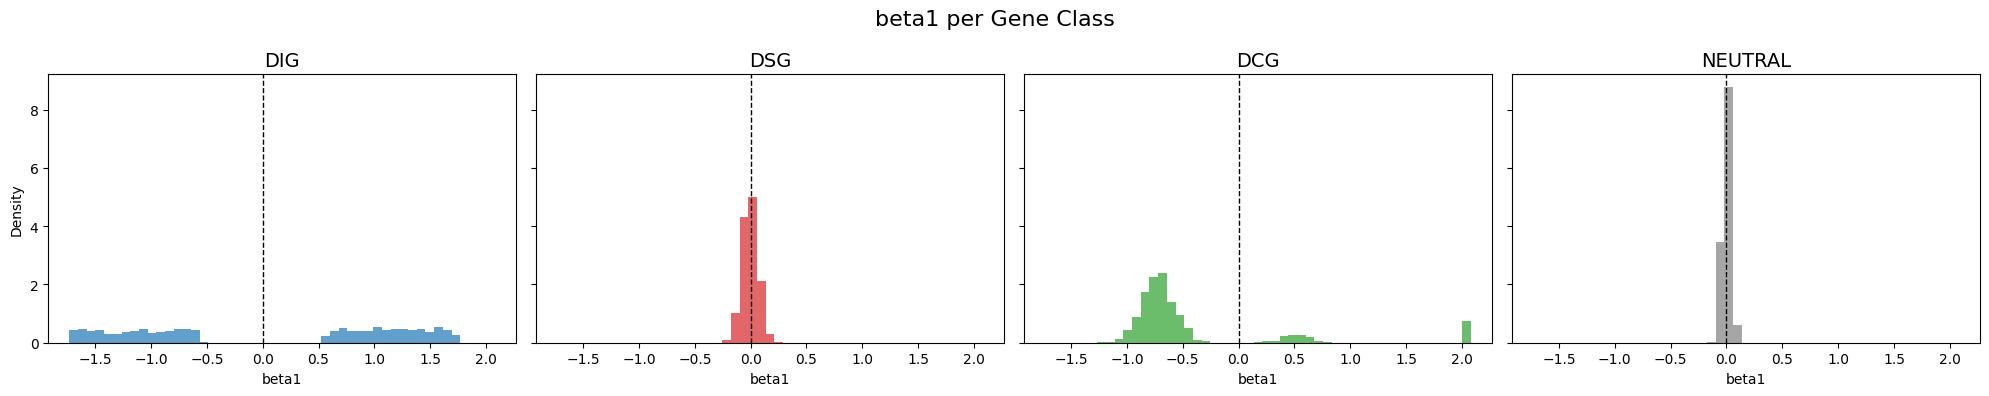

In [129]:
plot_faceted_histograms_beta1(truth_df, save_path="plots/beta1_facets.png")

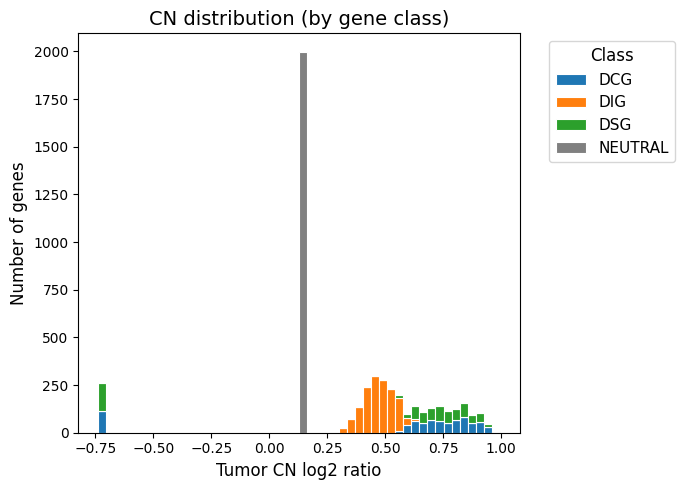

In [239]:
# CNV distribution by gene class

fig = plt.figure(figsize=(7,5))

# Define a strong, distinct palette
palette = {
    "DCG": "#1f77b4",   # blue
    "DIG": "#ff7f0e",   # orange
    "DSG": "#2ca02c",   # green
    "NEUTRAL": "gray" # red
}

# Precompute common bins
values_all = truth_df["cn_ratio_log2"]
counts, bin_edges = np.histogram(values_all, bins=50)

# Plot stacked with fixed colors
to_stack = []
labels = []

for cls, df_sub in truth_df.groupby("class"):
    to_stack.append(df_sub["cn_ratio_log2"])
    labels.append(cls)

plt.hist(
    to_stack,
    bins=bin_edges,
    stacked=True,
    label=labels,
    color=[palette.get(l, "#777777") for l in labels],
    edgecolor="white",
    linewidth=0.8
)

plt.xlabel("Tumor CN log2 ratio", fontsize=12)
plt.ylabel("Number of genes", fontsize=12)
plt.title("CN distribution (by gene class)", fontsize=14)

# Cleaner legend outside the plot
plt.legend(title="Class", fontsize=11, title_fontsize=12, bbox_to_anchor=(1.05,1), loc="upper left")

plt.tight_layout()

save_path = 'plots/hist_cn_ratio.png'

fig.savefig(save_path, dpi=400, bbox_inches="tight")
plt.show()

In [133]:
# Scatter Plot: CN-naive vs CN-aware log2FC

def plot_naive_vs_aware_LFC(truth_df, figsize=(7, 7), alpha=0.5, s=12, downsample=None, save_path="plots/scatter_LFC.png"):
    """
    Scatter plot comparing Naive vs CN-aware true log2FC.

    Parameters
    ----------
    truth_df : DataFrame
        Must contain:
            - empirical_log2FC_naive
            - empirical_log2FC_aware
            - class_new  (DIG / DSG / DCG / NEUTRAL)

    figsize : tuple
        Figure size.

    alpha : float
        Point transparency.

    s : int
        Marker size.

    downsample : int or None
        If provided, randomly subsample the genes to this number.

    save_path : str
        Where to save the figure.
    """

    df = truth_df.copy()

    # Optional downsampling for very large data
    if downsample is not None and len(df) > downsample:
        df = df.sample(n=downsample, replace=False, random_state=1)

    # Class → color mapping
    class_colors = {
        "DIG": "blue",
        "DSG": "red",
        "DCG": "green",
        "NEUTRAL": "gray"
    }

    # Prepare figure and capture object
    fig = plt.figure(figsize=figsize)

    # Plot each class separately
    for cls, color in class_colors.items():
        sub = df[df["class"] == cls]
        plt.scatter(
            sub["truth_log2FC_naive"],
            sub["truth_log2FC_aware"],
            s=s,
            alpha=alpha,
            color=color,
            label=cls,
        )

    # Reference lines
    plt.axhline(0, color="black", linestyle="--", linewidth=1)
    plt.axvline(0, color="black", linestyle="--", linewidth=1)

    plt.xlabel("Expected CN-naive truth log2FC")
    plt.ylabel("Expected CN-aware truth log2FC")
    plt.title("CN-naive vs CN-aware True log2FC")

    plt.legend(title="Gene class")
    plt.grid(False)
    plt.tight_layout()

    # Ensure directory exists and save
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    fig.savefig(save_path, dpi=400, bbox_inches="tight")

    plt.show()

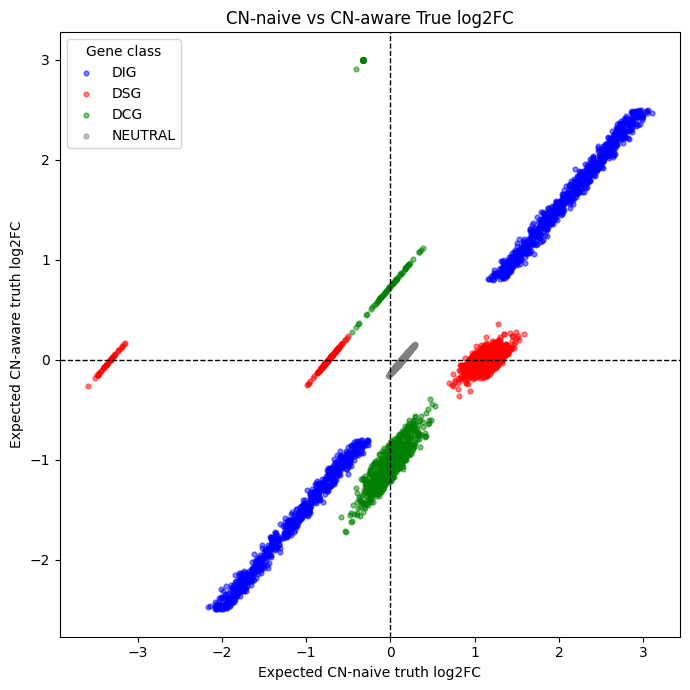

In [135]:
truth_df = sim["truth"]
plot_naive_vs_aware_LFC(truth_df)

In [137]:
def plot_naive_vs_aware_LFC(truth_df, figsize=(7, 7), alpha=0.5, s=12, downsample=None, save_path="plots/scatter_LFC.png"):
    """
    Scatter plot comparing Naive vs CN-aware true log2FC.

    Parameters
    ----------
    truth_df : DataFrame
        Must contain:
            - empirical_log2FC_naive
            - empirical_log2FC_aware
            - class_new  (DIG / DSG / DCG / NEUTRAL)

    figsize : tuple
        Figure size.

    alpha : float
        Point transparency.

    s : int
        Marker size.

    downsample : int or None
        If provided, randomly subsample the genes to this number.

    save_path : str
        Where to save the figure.
    """

    df = truth_df.copy()

    # Optional downsampling for very large data
    if downsample is not None and len(df) > downsample:
        df = df.sample(n=downsample, replace=False, random_state=1)

    # Class → color mapping
    class_colors = {
        "DIG": "blue",
        "DSG": "red",
        "DCG": "green",
        "NEUTRAL": "gray"
    }

    # Prepare figure and capture object
    fig = plt.figure(figsize=figsize)

    # Plot each class separately
    for cls, color in class_colors.items():
        sub = df[df["class"] == cls]
        plt.scatter(
            sub["empirical_log2FC_naive"],
            sub["empirical_log2FC_aware"],
            s=s,
            alpha=alpha,
            color=color,
            label=cls,
        )

    # Reference lines
    plt.axhline(0, color="black", linestyle="--", linewidth=1)
    plt.axvline(0, color="black", linestyle="--", linewidth=1)

    plt.xlabel("empirical CN-naive truth log2FC")
    plt.ylabel("empirical CN-aware truth log2FC")
    plt.title("CN-naive vs CN-aware empirical log2FC")

    plt.legend(title="Gene class")
    plt.grid(False)
    plt.tight_layout()

    # Ensure directory exists and save
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    fig.savefig(save_path, dpi=400, bbox_inches="tight")

    plt.show()

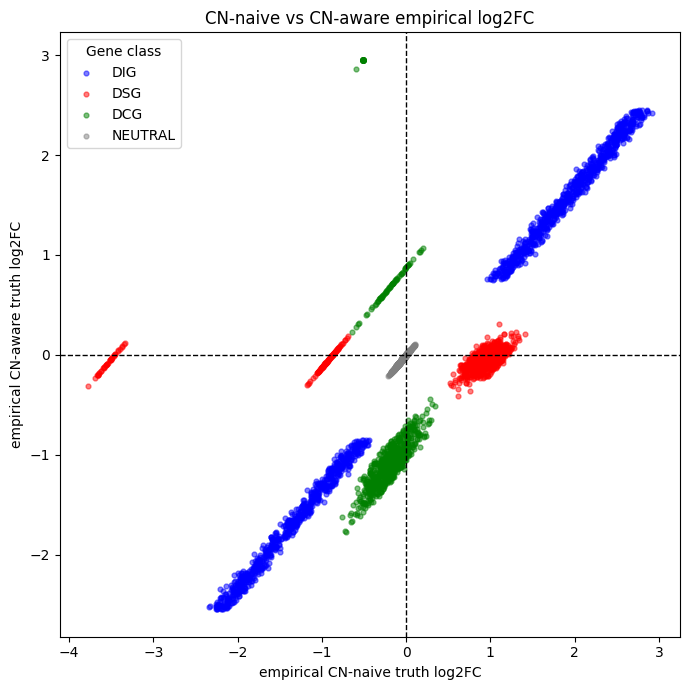

In [139]:
truth_df = sim["truth"]
plot_naive_vs_aware_LFC(truth_df)

In [53]:
with open("sim_results/sim_2.pkl", "wb") as f:
    pickle.dump(sim, f)

with open("sim_results/sim.pkl", "rb") as f:
    sim = pickle.load(f)

#### Test PyDESeq2 and DeConveil

In [241]:
cn_df  = sim["CN"]
counts_df = sim["counts"]
meta = sim["metadata"]
meta["condition"] = meta["condition"].replace({
    "normal": "A",
    "tumor": "B"
})

In [243]:
def run_pydeseq2(rna_counts, metadata, output_path, design="~condition", alpha=0.05):
    """
    Runs PyDESeq2 analysis and saves the results.

    Parameters:
        rna_counts (pd.DataFrame): Count matrix with genes as rows and samples as columns.
        metadata (pd.DataFrame): Metadata for the samples with design factors.
        output_path (str): Directory to save the results.
        design_factors (str): Column in metadata to use for design.
        alpha (float): Significance level for statistical tests.
    """
    os.makedirs(output_path, exist_ok=True)
    
    # Initialize DESeq2 analysis
    inference = DefaultInference(n_cpus=8)
    dds = DeseqDataSet(
        counts=rna_counts,
        metadata=metadata,
        design_factors=None,  # compare samples based on condition
        refit_cooks=True,
        inference=inference,
    )

    # Fit DESeq2 model
    dds.fit_size_factors()
    dds.fit_genewise_dispersions()
    dds.fit_dispersion_trend()
    dds.fit_dispersion_prior()
    dds.fit_MAP_dispersions()
    dds.fit_LFC()
    dds.calculate_cooks()
    
    if dds.refit_cooks:
        dds.refit()

    # Perform statistical analysis
    stat_res_pydeseq = DeseqStats(dds, 
                                  alpha=alpha, 
                                  cooks_filter=True, 
                                  independent_filter=True, 
                                  contrast=["condition", "B", "A"])
    stat_res_pydeseq.run_wald_test()

    if stat_res_pydeseq.cooks_filter:
        stat_res_pydeseq._cooks_filtering()
    stat_res_pydeseq.p_values

    if stat_res_pydeseq.independent_filter:
        stat_res_pydeseq._independent_filtering()
    else:
        stat_res_pydeseq._p_value_adjustment()

    # Log-fold change shrinkage
    stat_res_pydeseq.lfc_shrink(coeff="condition[T.B]")
    stat_res_pydeseq.summary()

    # Save results
    results_path = os.path.join(output_path, "res_CNnaive.csv")
    stat_res_pydeseq.results_df.to_csv(results_path)
    return(stat_res_pydeseq.results_df)
    

def run_deconveil(rna_counts, metadata, cnv, output_path, design="~condition", alpha=0.05):
    """
    Runs DeConveil analysis and saves the results.

    Parameters:
        rna_counts (pd.DataFrame): Count matrix with genes as rows and samples as columns.
        metadata (pd.DataFrame): Metadata for the samples with design factors.
        cnv (pd.DataFrame): Copy number variation (CNV) data matrix  with genes as rows and samples as columns.
        output_path (str): Directory to save the results.
        design_factors (str): Column in metadata to use for design.
        alpha (float): Significance level for statistical tests.
    """
    os.makedirs(output_path, exist_ok=True)
    
    # Initialize DeConveil inference
    inference = DefInference(n_cpus=8)

    # Fit DeConveil model
    dds = deconveil_fit(
        counts=rna_counts,
        metadata=metadata,
        cnv=cnv,
        design_factors="condition",
        inference=inference,
        refit_cooks=True
    )
    dds.fit_size_factors()
    dds.fit_genewise_dispersions()
    dds.fit_dispersion_trend()
    dds.fit_dispersion_prior()
    dds.fit_MAP_dispersions()
    dds.fit_LFC()
    dds.calculate_cooks()

    if dds.refit_cooks:
        dds.refit()  # Replace outlier counts

    # Statistical analysis
    stat_res_deconveil = deconveil_stats(
        dds, 
        alpha=alpha, 
        contrast=["condition", "B", "A"],
        independent_filter=True, 
        cooks_filter=True
    )
    stat_res_deconveil.run_wald_test()

    if stat_res_deconveil.independent_filter:
        stat_res_deconveil._independent_filtering()
    else:
        stat_res_deconveil._p_value_adjustment()

    # Log-fold change shrinkage
    stat_res_deconveil.lfc_shrink(coeff="condition[T.B]")
    stat_res_deconveil.summary()

    # Save results
    results_path = os.path.join(output_path, "res_CNaware.csv")
    stat_res_deconveil.results_df.to_csv(results_path)
    return(stat_res_deconveil.results_df)

In [247]:
# PyDESeq2
counts = counts_df.T
pydeseq2_output_path = "sim_results/"
res_naive = run_pydeseq2(counts, meta, pydeseq2_output_path)

Using None as control genes, passed at DeseqDataSet initialization


/opt/anaconda3/lib/python3.11/site-packages/anndata/_core/anndata.py:1792: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
Fitting size factors...
... done in 0.02 seconds.

Fitting dispersions...
... done in 1.10 seconds.

Fitting dispersion trend curve...
... done in 0.09 seconds.

Fitting MAP dispersions...
... done in 1.46 seconds.

Fitting LFCs...
... done in 0.71 seconds.

Calculating cook's distance...
... done in 0.07 seconds.

/opt/anaconda3/lib/python3.11/site-packages/anndata/_core/anndata.py:1792: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
Replacing 106 outlier genes.

/opt/anaconda3/lib/python3.11/site-packages/anndata/_core/anndata.py:1792: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/lib/p

Log2 fold change & Wald test p-value: condition B vs A
              baseMean  log2FoldChange     lfcSE       stat         pvalue  \
NPFF      8.866197e+03       -0.793229  0.287293  -3.043372   2.339427e-03   
MTX2      1.492617e+05        0.050161  0.091174   0.423640   6.718284e-01   
VGLL4     4.104921e+05       -1.580559  0.121183 -13.271589   3.383315e-40   
ZNF451    8.175477e+05        2.461812  0.094003  26.348810  5.296141e-153   
RPS3A     1.213724e+06       -0.030448  0.121219  -0.469800   6.384979e-01   
...                ...             ...       ...        ...            ...   
ANKRD46   1.092118e+05       -0.082269  0.403608  -0.268810   7.880762e-01   
RPL34P18  1.182251e+05        0.085766  0.528128   0.231820   8.166775e-01   
NACA      2.013030e+06       -1.638276  0.127927 -13.101966   3.208378e-39   
SSX2IP    1.037566e+05       -0.237715  0.217706  -1.191713   2.333737e-01   
POU2F2    2.279409e+04       -1.690986  0.137697 -12.420634   2.019535e-35   

        

... done in 1.22 seconds.



In [249]:
# DeConveil
cn_df = cn_df.T
deconveil_output_path = "sim_results/"
res_aware = run_deconveil(counts, meta, cn_df, deconveil_output_path)  

/var/folders/mh/vvy722dj18x7xj41n2qbdzs80000gn/T/ipykernel_1480/2991058971.py:19: DeprecationWarning: design_factors are deprecated and will soon be removedPlease consider providing a formulaic formula using the design argument instead
  dds = deconveil_fit(
Fitting size factors...
... done in 0.02 seconds.



Using None as control genes, passed at deconveil_fit initialization


Fitting dispersions...
... done in 1.09 seconds.

Fitting dispersion trend curve...
... done in 0.08 seconds.

Fitting MAP dispersions...
... done in 1.46 seconds.

Fitting LFCs...
... done in 0.93 seconds.

Calculating cook's distance...
... done in 0.07 seconds.

Replacing 104 outlier genes.

Fitting dispersions...
... done in 0.05 seconds.

Fitting MAP dispersions...


replace_mask before filtering: (120, 104)
Number of True values in replace_mask: 157
replacement_counts_trimmed shape: (92, 104)


... done in 0.05 seconds.

Fitting LFCs...
... done in 0.05 seconds.

Running Wald tests...
... done in 0.44 seconds.

Fitting MAP LFCs...


Log2 fold change & Wald test p-value: condition B vs A
              baseMean  log2FoldChange     lfcSE       stat         pvalue  \
NPFF      8.866197e+03       -0.960900  0.294576  -4.303786   1.679035e-05   
MTX2      1.492617e+05        2.056043  0.096938   0.423639   6.718292e-01   
VGLL4     4.104921e+05        0.593485  0.122443 -15.815540   2.431163e-56   
ZNF451    8.175477e+05        3.372069  0.065570  21.325169  6.631325e-101   
RPS3A     1.213724e+06        1.988667  0.069716  -0.469800   6.384980e-01   
...                ...             ...       ...        ...            ...   
ANKRD46   1.092118e+05        1.104722  0.367736  -1.800067   7.185004e-02   
RPL34P18  1.182251e+05        1.312302  0.385713  -1.103145   2.699641e-01   
NACA      2.013030e+06        0.807505  0.071607 -16.694769   1.430718e-62   
SSX2IP    1.037566e+05        1.384596  0.198099  -1.191711   2.333746e-01   
POU2F2    2.279409e+04       -2.162522  0.135750 -15.154934   7.028546e-52   

        

... done in 1.87 seconds.



In [251]:
classes       = truth_df["class"]
truth_DE   = truth_df["DE_truth"]
deseq2_lfc_shrunk = res_naive["log2FoldChange"]
deconveil_lfc_shrunk = res_aware["log2FoldChange"]

alpha = 0.05
res_naive["is_DE"]   = res_naive["padj"]   < alpha
res_naive

In [255]:
alpha = 0.05
res_aware["is_DE"]   = res_aware["padj"]   < alpha
res_aware

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,is_DE
NPFF,8.866197e+03,-0.960900,0.294576,-4.303786,1.679035e-05,5.568502e-05,True
MTX2,1.492617e+05,2.056043,0.096938,0.423639,6.718292e-01,7.894191e-01,False
VGLL4,4.104921e+05,0.593485,0.122443,-15.815540,2.431163e-56,7.261461e-55,True
ZNF451,8.175477e+05,3.372069,0.065570,21.325169,6.631325e-101,6.891052e-99,True
RPS3A,1.213724e+06,1.988667,0.069716,-0.469800,6.384980e-01,7.639309e-01,False
...,...,...,...,...,...,...,...
ANKRD46,1.092118e+05,1.104722,0.367736,-1.800067,7.185004e-02,1.433721e-01,False
RPL34P18,1.182251e+05,1.312302,0.385713,-1.103145,2.699641e-01,4.245699e-01,False
NACA,2.013030e+06,0.807505,0.071607,-16.694769,1.430718e-62,5.171318e-61,True
SSX2IP,1.037566e+05,1.384596,0.198099,-1.191711,2.333746e-01,3.805401e-01,False


In [161]:
def plot_deseq2_vs_truth_naive(truth_df, 
                               deseq2_lfc_shrunk, 
                               classes, figsize=(6, 6), alpha=0.4, s=5, 
                               save_path="plots/deseq2_vs_truth_naive.png"):

    # Extract values
    truth_naive = truth_df["truth_log2FC_naive"]

    palette = {
        "DIG": "blue",
        "DSG": "red",
        "DCG": "green",
        "NEUTRAL": "gray"
    }

    # Compute Pearson correlation
    r, pval = pearsonr(truth_naive, deseq2_lfc_shrunk)

    # Create figure and capture object
    fig = plt.figure(figsize=figsize)

    # Plot per class
    for cls in np.unique(classes):
        idx = (classes == cls)
        plt.scatter(truth_naive[idx], deseq2_lfc_shrunk[idx],
                    s=s, alpha=alpha, label=cls, color=palette.get(cls, "#7f7f7f"))

    # 45° identity line
    plt.axline((0, 0), (1, 1), color='black')

    plt.axis("equal")

    plt.axvline(0, linewidth=1)
    plt.axhline(0, linewidth=1)

    lim = max(abs(truth_naive).max(), abs(deseq2_lfc_shrunk).max())
    plt.xlim(-lim, lim)
    plt.ylim(-lim, lim)

    plt.grid(True, which="both", linewidth=0.5)

    raw_ticks = np.linspace(-lim, lim, 10)
    rounded_ticks = np.round(raw_ticks, 0)
    plt.xticks(rounded_ticks)
    plt.yticks(rounded_ticks)

    plt.text(
        0.03, 0.97, f"Pearson r = {r:.3f}", transform=plt.gca().transAxes,
        fontsize=10, verticalalignment='top'
    )

    plt.xlabel("Truth LFC-naive")
    plt.ylabel("DESeq2 LFC shrink")
    plt.legend()
    plt.title("Per-class CN-naive")
    plt.tight_layout()

    # Ensure directory exists and save plot correctly
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    fig.savefig(save_path, dpi=400, bbox_inches="tight")

    plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


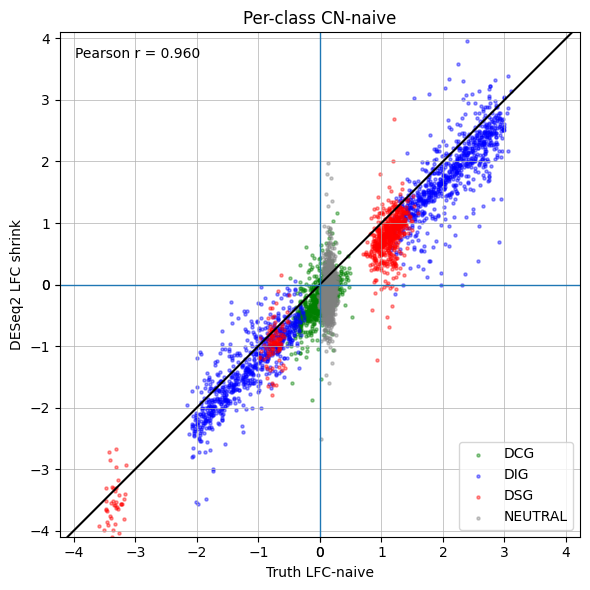

In [163]:
fig = plot_deseq2_vs_truth_naive(
    truth_df,
    deseq2_lfc_shrunk=deseq2_lfc_shrunk,
    classes=truth_df["class"],
    save_path="plots/LFC_truth_vs_deseq2.png"
)

In [165]:
truth_aware = truth_df["truth_log2FC_aware"]

def plot_deconveil_vs_truth_aware(truth_df, deconveil_lfc_shrunk, classes,
                                 figsize=(6, 6), alpha=0.4, s=5,
                                 palette=None,
                                 save_path="plots/deconveil_vs_truth_aware.png"):

    truth_aware = truth_df["truth_log2FC_aware"]

    # Default palette if none supplied
    if palette is None:
        palette = {
            "DIG": "blue",
            "DSG": "red",
            "DCG": "green",
            "NEUTRAL": "gray"
        }

    # Compute Pearson correlation
    r, pval = pearsonr(truth_aware, deconveil_lfc_shrunk)

    # Create figure and capture object
    fig = plt.figure(figsize=figsize)

    # Plot each class
    for cls in np.unique(classes):
        idx = (classes == cls)
        plt.scatter(truth_aware[idx], deconveil_lfc_shrunk[idx],
                    s=s, alpha=alpha, label=cls, color=palette.get(cls, "#7f7f7f"))

    # Identity line (45°)
    plt.axline((0, 0), (1, 1), color='black')

    plt.axis("equal")
    plt.axvline(0, linewidth=1)
    plt.axhline(0, linewidth=1)

    lim = max(abs(truth_aware).max(), abs(deconveil_lfc_shrunk).max())
    plt.xlim(-lim, lim)
    plt.ylim(-lim, lim)

    plt.grid(True, which="both", linewidth=0.5)

    raw_ticks = np.linspace(-lim, lim, 10)
    rounded_ticks = np.round(raw_ticks, 0)
    plt.xticks(rounded_ticks)
    plt.yticks(rounded_ticks)

    # Correlation text
    plt.text(
        0.03, 0.97, f"Pearson r = {r:.3f}", transform=plt.gca().transAxes,
        fontsize=10, verticalalignment='top'
    )

    plt.xlabel("Truth LFC-aware")
    plt.ylabel("DeConveil LFC shrink")
    plt.legend()
    plt.title("Per-class CN-aware")
    plt.tight_layout()

    # Ensure folder exists and save
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    fig.savefig(save_path, dpi=400, bbox_inches="tight")

    plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


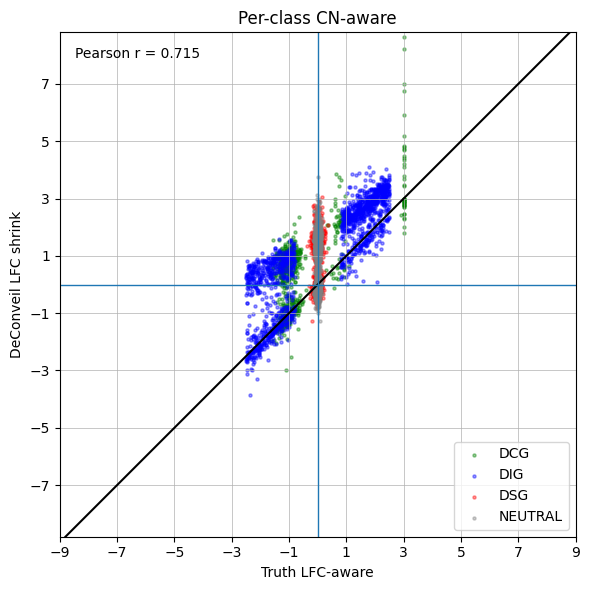

In [167]:
fig = plot_deconveil_vs_truth_aware(
    truth_df,
    deconveil_lfc_shrunk=deconveil_lfc_shrunk,
    classes=truth_df["class"],
    save_path="plots/LFC_truth_aware_vs_DeConveil.png"
)

In [171]:
# for each class check stats 
truth_df.groupby("class")[["empirical_log2FC_naive","empirical_log2FC_aware"]].agg(["mean","std","min","max"])

empirical_log2FC_naive                                \
                          mean       std       min       max   
class                                                          
DCG                  -0.208226  0.197784 -0.763194  0.341425   
DIG                   0.383141  1.724430 -2.335874  2.916055   
DSG                   0.426748  1.156255 -3.774435  1.407360   
NEUTRAL              -0.047405  0.050114 -0.208657  0.104646   

        empirical_log2FC_aware                                
                          mean       std       min       max  
class                                                         
DCG                  -0.691469  1.063216 -1.770232  2.952422  
DIG                   0.049402  1.722964 -2.544125  2.451491  
DSG                  -0.053371  0.101175 -0.411982  0.314274  
NEUTRAL              -0.047405  0.050114 -0.208657  0.104646

In [175]:
# for each class check stats - estimated
#df_res_comparison.groupby("class")[["log2FC_deseq2_shrunk","log2FC_deconveil_shrunk"]].agg(["mean","std","min","max"])

In [257]:
res1_df, res2_df, res_pydeseq_updated, res_deconveil_updated = run_stageR(res_naive, res_aware)
print(res1_df.head())
print(res2_df.head())
print(res_pydeseq_updated.head())
print(res_deconveil_updated.head())

R callback write-console: The returned adjusted p-values are based on a stage-wise testing approach and are only valid for the provided target OFDR level of 5%. If a different target OFDR level is of interest,the entire adjustment should be re-run. 

  
R callback write-console: The returned adjusted p-values are based on a stage-wise testing approach and are only valid for the provided target OFDR level of 5%. If a different target OFDR level is of interest,the entire adjustment should be re-run. 

  


           padjScreen        p_naive        p_aware
NPFF     3.358070e-05   4.229453e-03   3.035530e-05
MTX2     6.718292e-01            NaN            NaN
VGLL4    4.862325e-56   6.116699e-40   4.395302e-56
ZNF451  1.059228e-152  9.574901e-153  1.198878e-100
RPS3A    6.384980e-01            NaN            NaN
        padjScreen  p_naive  p_aware
NPFF           1.0      1.0      1.0
MTX2           0.0      0.0      0.0
VGLL4          1.0      1.0      1.0
ZNF451         1.0      1.0      1.0
RPS3A          0.0      0.0      0.0
            baseMean  log2FoldChange     lfcSE       stat         pvalue  \
NPFF    8.866197e+03       -0.793229  0.287293  -3.043372   2.339427e-03   
MTX2    1.492617e+05        0.050161  0.091174   0.423640   6.718284e-01   
VGLL4   4.104921e+05       -1.580559  0.121183 -13.271589   3.383315e-40   
ZNF451  8.175477e+05        2.461812  0.094003  26.348810  5.296141e-153   
RPS3A   1.213724e+06       -0.030448  0.121219  -0.469800   6.384979e-01   

         

In [259]:
res_pydeseq_updated.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,is_DE,padjConfirm_naive_stageR
NPFF,8.866197e+03,-0.793229,0.287293,-3.043372,2.339427e-03,6.603883e-03,True,4.229453e-03
MTX2,1.492617e+05,0.050161,0.091174,0.423640,6.718284e-01,7.855321e-01,False,7.855321e-01
VGLL4,4.104921e+05,-1.580559,0.121183,-13.271589,3.383315e-40,6.027133e-39,True,6.116699e-40
ZNF451,8.175477e+05,2.461812,0.094003,26.348810,5.296141e-153,1.651072e-150,True,9.574901e-153
RPS3A,1.213724e+06,-0.030448,0.121219,-0.469800,6.384979e-01,7.588343e-01,False,7.588343e-01


In [261]:
res_deconveil_updated.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,is_DE,padjConfirm_aware_stageR
NPFF,8.866197e+03,-0.960900,0.294576,-4.303786,1.679035e-05,5.568502e-05,True,3.035530e-05
MTX2,1.492617e+05,2.056043,0.096938,0.423639,6.718292e-01,7.894191e-01,False,7.894191e-01
VGLL4,4.104921e+05,0.593485,0.122443,-15.815540,2.431163e-56,7.261461e-55,True,4.395302e-56
ZNF451,8.175477e+05,3.372069,0.065570,21.325169,6.631325e-101,6.891052e-99,True,1.198878e-100
RPS3A,1.213724e+06,1.988667,0.069716,-0.469800,6.384980e-01,7.639309e-01,False,7.639309e-01


In [263]:
df = pd.DataFrame({
    "gene": res_pydeseq_updated.index,
    "padj_pnaive_BH": res_pydeseq_updated["padj"],
    "padj_pnaive_stageR": res_pydeseq_updated["padjConfirm_naive_stageR"],
    "padj_paware_BH": res_deconveil_updated["padj"],
    "padj_paware_stageR": res_deconveil_updated["padjConfirm_aware_stageR"],
}).set_index("gene")
df.head()

,padj_pnaive_BH,padj_pnaive_stageR,padj_paware_BH,padj_paware_stageR
gene,,,,
NPFF,6.603883e-03,4.229453e-03,5.568502e-05,3.035530e-05
MTX2,7.855321e-01,7.855321e-01,7.894191e-01,7.894191e-01
VGLL4,6.027133e-39,6.116699e-40,7.261461e-55,4.395302e-56
ZNF451,1.651072e-150,9.574901e-153,6.891052e-99,1.198878e-100
RPS3A,7.588343e-01,7.588343e-01,7.639309e-01,7.639309e-01


In [265]:
alpha = 0.05
df["is_DE_naive"]= df["padj_pnaive_stageR"]   < alpha
df["is_DE_aware"]= df["padj_paware_stageR"]   < alpha
df

,padj_pnaive_BH,padj_pnaive_stageR,padj_paware_BH,padj_paware_stageR,is_DE_naive,is_DE_aware
gene,,,,,,
NPFF,6.603883e-03,4.229453e-03,5.568502e-05,3.035530e-05,True,True
MTX2,7.855321e-01,7.855321e-01,7.894191e-01,7.894191e-01,False,False
VGLL4,6.027133e-39,6.116699e-40,7.261461e-55,4.395302e-56,True,True
ZNF451,1.651072e-150,9.574901e-153,6.891052e-99,1.198878e-100,True,True
RPS3A,7.588343e-01,7.588343e-01,7.639309e-01,7.639309e-01,False,False
...,...,...,...,...,...,...
ANKRD46,8.703426e-01,8.703426e-01,1.433721e-01,1.433721e-01,False,False
RPL34P18,8.876687e-01,8.876687e-01,4.245699e-01,4.245699e-01,False,False
NACA,5.537505e-38,5.800431e-39,5.171318e-61,2.586596e-62,True,True


In [267]:
truth_df

,class,beta1,cn_ratio_log2,truth_log2FC_aware,truth_log2FC_naive,empirical_log2FC_naive,empirical_log2FC_aware,DE_truth
NPFF,DIG,-0.665715,0.450661,-0.960424,-0.509762,-0.695082,-1.008002,True
MTX2,NEUTRAL,0.063703,0.137504,0.091904,0.229408,0.044326,0.044326,False
VGLL4,DIG,-1.161636,0.459432,-1.675887,-1.216455,-1.387704,-1.723465,True
ZNF451,DIG,1.415988,0.608809,2.042839,2.651648,2.468481,1.995261,True
RPS3A,NEUTRAL,0.018586,0.137504,0.026813,0.164317,-0.020765,-0.020765,False
...,...,...,...,...,...,...,...,...
ANKRD46,DCG,-0.538939,0.821030,-0.777524,0.043506,-0.139459,-0.825102,True
RPL34P18,DCG,-0.511653,0.867896,-0.738159,0.129737,-0.047738,-0.785737,True
NACA,DIG,-1.482133,0.600904,-2.138266,-1.537361,-1.726225,-2.185844,True
SSX2IP,NEUTRAL,-0.009300,0.137504,-0.013417,0.124086,-0.060995,-0.060995,False


In [269]:
from sklearn.metrics import confusion_matrix

# Single biological truth
true = truth_df["DE_truth"].astype(bool)

# Predictions from the two methods
pred_naive = df["is_DE_naive"].astype(bool)
pred_aware = df["is_DE_aware"].astype(bool)

for cls in truth_df["class"].unique():
    print(f"\n=== Class: {cls} ===")

    mask = (truth_df["class"] == cls)

    # CN-naive
    tn, fp, fn, tp = confusion_matrix(
        true[mask],
        pred_naive[mask],
        labels=[False, True]
    ).ravel()

    print("CN-naive:")
    print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")

    # CN-aware 
    tn, fp, fn, tp = confusion_matrix(
        true[mask],
        pred_aware[mask],
        labels=[False, True]
    ).ravel()

    print("CN-aware:")
    print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")


=== Class: DIG ===
CN-naive:
  TP=1390  FP=0  FN=106  TN=0
CN-aware:
  TP=1390  FP=0  FN=106  TN=0

=== Class: NEUTRAL ===
CN-naive:
  TP=0  FP=158  FN=0  TN=1837
CN-aware:
  TP=0  FP=174  FN=0  TN=1821

=== Class: DCG ===
CN-naive:
  TP=192  FP=0  FN=552  TN=5
CN-aware:
  TP=587  FP=1  FN=157  TN=4

=== Class: DSG ===
CN-naive:
  TP=7  FP=432  FN=5  TN=304
CN-aware:
  TP=5  FP=66  FN=7  TN=670


In [271]:
def plot_confusion_by_class(
    truth_df,
    res_naive,
    res_aware,
    classes=("NEUTRAL", "DSG", "DCG", "DIG"),
    figsize=(12, 10),
    title_prefix="Confusion matrices",
    save_path=None,
    dpi=300
):
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.metrics import confusion_matrix

    y_true = truth_df["DE_truth"].astype(bool)
    y_pred_naive = res_naive["is_DE_naive"].astype(bool)
    y_pred_aware = res_aware["is_DE_aware"].astype(bool)

    fig, axes = plt.subplots(
        len(classes), 2, figsize=figsize, squeeze=False
    )

    for i, cls in enumerate(classes):
        mask = (truth_df["class"] == cls)

        cm_naive = confusion_matrix(
            y_true[mask], y_pred_naive[mask], labels=[False, True]
        )
        cm_aware = confusion_matrix(
            y_true[mask], y_pred_aware[mask], labels=[False, True]
        )

        for j, (cm, method) in enumerate(
            [(cm_naive, "CN-naive"), (cm_aware, "CN-aware")]
        ):
            ax = axes[i, j]
            ax.imshow(cm, cmap="Blues")

            ax.set_xticks([0, 1])
            ax.set_yticks([0, 1])
            ax.set_xticklabels(["Not DE", "DE"])
            ax.set_yticklabels(["Not DE", "DE"])

            ax.set_xlabel("Predicted")
            ax.set_ylabel("Truth")

            ax.set_title(f"{cls} — {method}")

            for r in range(2):
                for c in range(2):
                    ax.text(
                        c, r, cm[r, c],
                        ha="center", va="center",
                        fontsize=11
                    )

    plt.suptitle(title_prefix, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # Save if requested
    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"[SAVED] {save_path}")

    plt.show()


[SAVED] plots/confusion_mat_CNweak.png


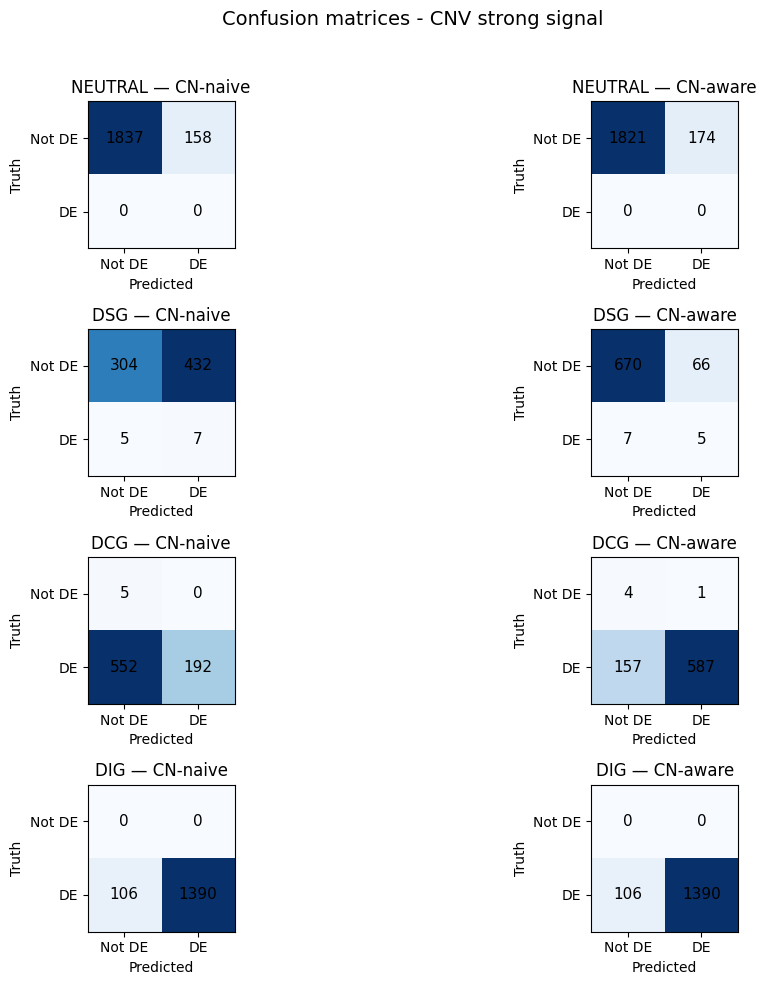

In [273]:
plot_confusion_by_class(
    truth_df=truth_df,
    title_prefix = "Confusion matrices - CNV strong signal",
    res_naive=df,
    res_aware=df,
    save_path="plots/confusion_mat_CNweak.png"
)

#### Explore simulations fit

In [275]:
truth_df = pd.read_csv("sim_results/sim_res_fit/truth_S60_G5000_CNstrong_R1.csv")
res_naive = pd.read_csv("sim_results/sim_res_fit/res_CNnaive_S60_G5000_CNstrong_R1.csv")
res_aware = pd.read_csv("sim_results/sim_res_fit/res_CNaware_S60_G5000_CNstrong_R1.csv")

In [277]:
alpha = 0.05
res_naive["is_DE_naive"] = res_naive["padjConfirm_naive_stageR"] < alpha
res_aware["is_DE_aware"] = res_aware["padjConfirm_aware_stageR"] < alpha

In [281]:
# Single biological truth
true = truth_df["DE_truth"].astype(bool)

# Predictions from the two methods
pred_naive = res_naive["is_DE_naive"].astype(bool)
pred_aware = res_aware["is_DE_aware"].astype(bool)

for cls in truth_df["class"].unique():
    print(f"\n=== Class: {cls} ===")

    mask = (truth_df["class"] == cls)

    # CN-naive
    tn, fp, fn, tp = confusion_matrix(
        true[mask],
        pred_naive[mask],
        labels=[False, True]
    ).ravel()

    print("CN-naive:")
    print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")

    # CN-aware 
    tn, fp, fn, tp = confusion_matrix(
        true[mask],
        pred_aware[mask],
        labels=[False, True]
    ).ravel()

    print("CN-aware:")
    print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")


=== Class: NEUTRAL ===
CN-naive:
  TP=0  FP=169  FN=0  TN=1829
CN-aware:
  TP=0  FP=196  FN=0  TN=1802

=== Class: DSG ===
CN-naive:
  TP=6  FP=599  FN=6  TN=138
CN-aware:
  TP=0  FP=81  FN=12  TN=656

=== Class: DCG ===
CN-naive:
  TP=221  FP=2  FN=527  TN=0
CN-aware:
  TP=636  FP=0  FN=112  TN=2

=== Class: DIG ===
CN-naive:
  TP=1367  FP=0  FN=131  TN=0
CN-aware:
  TP=1390  FP=0  FN=108  TN=0


In [283]:
# CN weak signal
truth_df = pd.read_csv("sim_results/sim_res_fit/truth_S60_G5000_CNweak_R1.csv")
res_naive = pd.read_csv("sim_results/sim_res_fit/res_CNnaive_S60_G5000_CNweak_R1.csv")
res_aware = pd.read_csv("sim_results/sim_res_fit/res_CNaware_S60_G5000_CNweak_R1.csv")

In [285]:
alpha = 0.05
res_naive["is_DE_naive"] = res_naive["padjConfirm_naive_stageR"] < alpha
res_aware["is_DE_aware"] = res_aware["padjConfirm_aware_stageR"] < alpha

In [287]:
# Single biological truth
true = truth_df["DE_truth"].astype(bool)

# Predictions from the two methods
pred_naive = res_naive["is_DE_naive"].astype(bool)
pred_aware = res_aware["is_DE_aware"].astype(bool)

for cls in truth_df["class"].unique():
    print(f"\n=== Class: {cls} ===")

    mask = (truth_df["class"] == cls)

    # CN-naive
    tn, fp, fn, tp = confusion_matrix(
        true[mask],
        pred_naive[mask],
        labels=[False, True]
    ).ravel()

    print("CN-naive:")
    print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")

    # CN-aware 
    tn, fp, fn, tp = confusion_matrix(
        true[mask],
        pred_aware[mask],
        labels=[False, True]
    ).ravel()

    print("CN-aware:")
    print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")


=== Class: NEUTRAL ===
CN-naive:
  TP=0  FP=95  FN=0  TN=1903
CN-aware:
  TP=0  FP=131  FN=0  TN=1867

=== Class: DSG ===
CN-naive:
  TP=3  FP=468  FN=9  TN=269
CN-aware:
  TP=3  FP=56  FN=9  TN=681

=== Class: DCG ===
CN-naive:
  TP=180  FP=5  FN=559  TN=6
CN-aware:
  TP=566  FP=4  FN=173  TN=7

=== Class: DIG ===
CN-naive:
  TP=1355  FP=0  FN=143  TN=0
CN-aware:
  TP=1386  FP=0  FN=112  TN=0
